## Безусловная генерация рентгеновских снимков

### Просмротр датасета

In [142]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image

from pathlib import Path

import kagglehub
import os

In [53]:
def download(variant=None):
    """
        p - dataset with pneumonia, path point to chest_xray where have test and train folders.
            in train 2 folders: NORMAL and PNEUMONIA (into on of folders .jpeg pictures)
        c - dataset with covid
        v - dataset with big variance of labels
    """
    path = ''
    if variant == 'p':
        path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
        print("Path to dataset files:", path)
        return path

    if variant == 'c':
        path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
        print("Path to dataset files:", path)
        return path
    
    if variant == 'v':
        path = kagglehub.dataset_download("mathurinache/chestxdetdataset")
        print("Path to dataset files:", path)
        return path

    print('huh?')

In [54]:
path = download('p')

Path to dataset files: C:\Users\panika\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [70]:
def analyze(path, v):
    if v == 'p':
        normal_path = path + '\\chest_xray\\train\\NORMAL'
        pneumonia_path = path + '\\chest_xray\\train\\PNEUMONIA'
        normal = os.listdir(normal_path)
        print(f'В файле количество нормальных здоровых: {len(normal)}')

        sick = os.listdir(pneumonia_path)
        print(f'В файле количество больных рентгенов: {len(sick)}')

        H = np.array([])
        W = np.array([])
        for sc in sick:
            img = read_image(pneumonia_path + '\\' + sc)
            H = np.append(H, img.shape[1])
            W = np.append(W, img.shape[2])

        fig, axs = plt.subplots(1, 2)
        axs[0].hist(H, color='blue', edgecolor='black')
        axs[0].set_title('Гистограмма по H (количество строк)')
        axs[0].grid()
        axs[1].hist(W, color='blue', edgecolor='black')
        axs[1].set_title('Гистрограмма по W (количество столбцов)')
        axs[1].grid()

        plt.tight_layout()
        plt.show()

В файле количество нормальных здоровых: 1341
В файле количество больных рентгенов: 3875


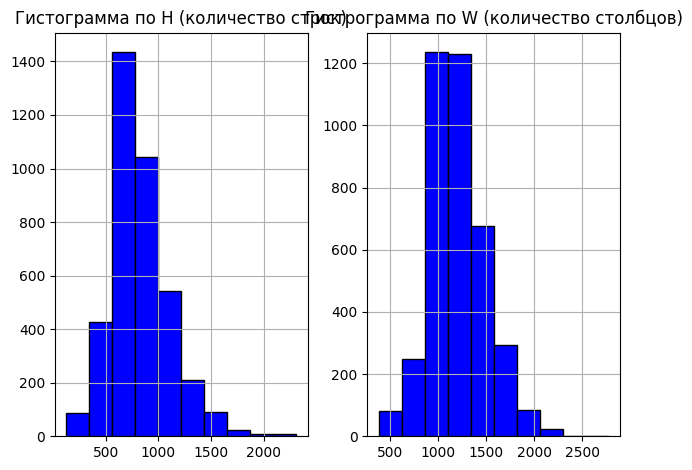

In [71]:
analyze(path, 'p')

Проболема большая - рентгены разного рзамера. Если сжимать их, например, до 256 на 256 может получиться не красивые мыльные изображения для обучающего набора, что является проблемой. Ладно попробуем 256 на 256 потом видно будет

In [140]:
def import_pirctures(path, v):
    if v == 'p':
        path = path + '\\chest_xray\\train'

        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        dataset = datasets.ImageFolder(root=path, transform=transform)
        print(len(dataset))
        plt.imshow(dataset[0][0][0], cmap='grey')
        plt.xticks([])
        plt.yticks([])
        return
    
    print('huh?')

5216


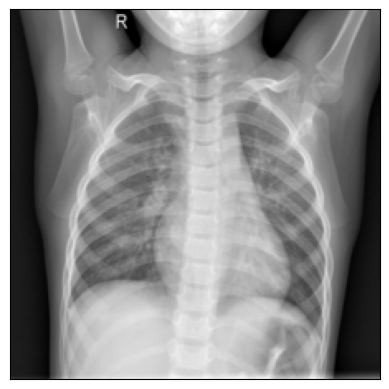

In [141]:
import_pirctures(path, 'p')

При предварительном просмотре рентгеновских снимков 256 на 256 оказались не такими плохими так, что пробуем дальше

### Написание архитектуры модели

In [ ]:
class Block(nn.Nodule):
    pass

class Unet():
    pass

### Заметки по датасетам

- covid19-radiography-database - датасет с ковидом и черными хуевыми масками
- https://www.kaggle.com/competitions/siim-acr-pneumothorax-segmentation/data - рентген + рисунке вроде притом нормальные рисунки, но есть пользовательское соглашение какое то странное и подтвеждение лица
- https://github.com/Deepwise-AILab/ChestX-Det-Dataset - нихуя не понял
- https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data - Нормальная и пневмония без схем
- https://github.com/ieee8023/covid-chestxray-dataset - какая-та хуйня с метоинформацией, но схем нет


Wasserthal et al., "TotalSegmentator: Robust Segmentation of 117 Anatomical Structures" (2023). - какая та интересная статья


### Информация

Saharia et al., "Palette: Image-to-Image Diffusion Models" (2022) - статья по получению изображения из изображения

https://arxiv.org/pdf/1901.00542 - что очень крутое, надо 100% прочитать

# Я в очке

Смешные галлюционации Gemeni

3. SOTA-решение: Каскадная Диффузия (Cascaded Diffusion)
Чтобы не выбирать между «мылом» и «анатомическим хаосом», в профессиональной медицине используют каскады.
Статья: Ho et al., "Cascaded Diffusion Models for High Fidelity Image Generation" (2022).
Архитектурное решение:
Low-Res Model (
64
×
64
64×64
 или 
128
×
128
128×128
): Обучается по твоей «Схеме». Её задача — выстроить анатомию (скелет, положение органов). Тут «мыло» допустимо.
Super-Resolution Model (SR): Вторая диффузионная модель. Она принимает на вход результат первой модели (апскейл до 
512
512
 или 
1024
1024
) и оригинальную схему. Её задача — навести резкость и текстуру, используя схему как направляющую.
Статья по SR: Saharia et al., "Image Super-Resolution via Iterative Refinement" (2022) (модель SR3).